In [1]:
from cantuccio import cornerplot

import numpy as np
import scipy
import matplotlib.pyplot as plt

import marimo as mo

## Start generating some data

In [2]:
def get_samples(means, vars, size):
    samples = []
    labels = []

    for i, (mu, var) in enumerate(zip(means, vars)):
        print(f"adding component {i}")
        _samples = scipy.stats.distributions.norm(mu, var).rvs(size)
        samples.append(_samples)
        labels.append(rf"$\mu_{i}$")

    return dict(zip(labels, np.stack(samples, axis=0)))

In [3]:
mus = [5, 3, 10]

first_chain = get_samples(mus, [2, 1, 5], 1000)

adding component 0
adding component 1
adding component 2


## let's see how they look

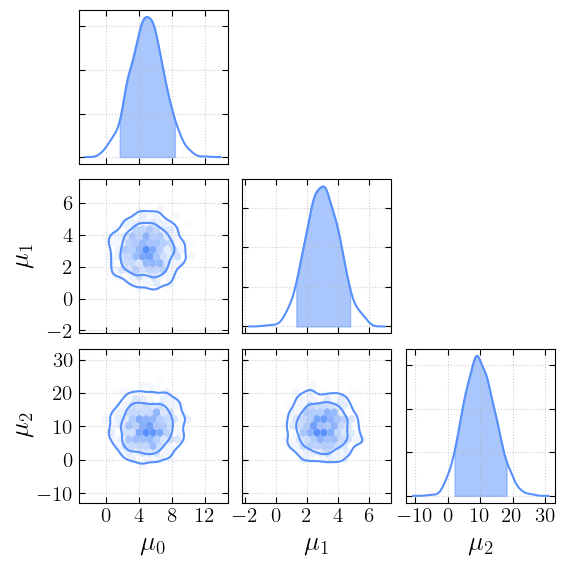

In [4]:
_ = cornerplot(samples=first_chain)
plt.show()

### We can now change the style...

In [5]:
from cantuccio.core import OFFDIAG_MODES
styles = mo.ui.dropdown(options=OFFDIAG_MODES, value='hexbin+kde')
styles

dropdown()

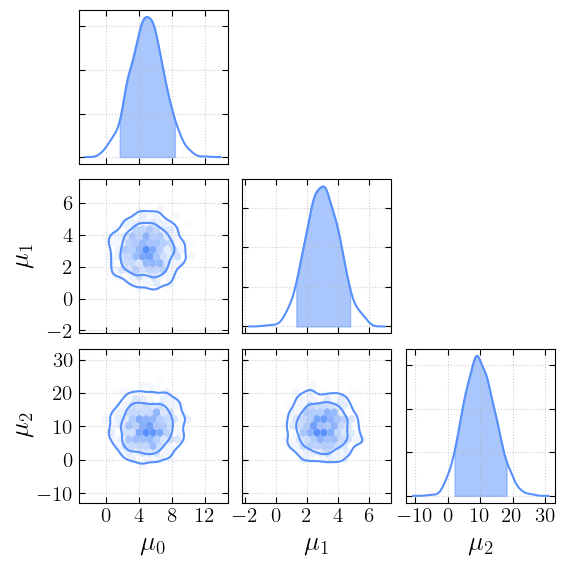

In [6]:
_ =cornerplot(samples=first_chain, offdiag_mode=styles.value)
plt.show()

### ... add the true values...

In [7]:
truths = dict(zip(first_chain.keys(), mus))

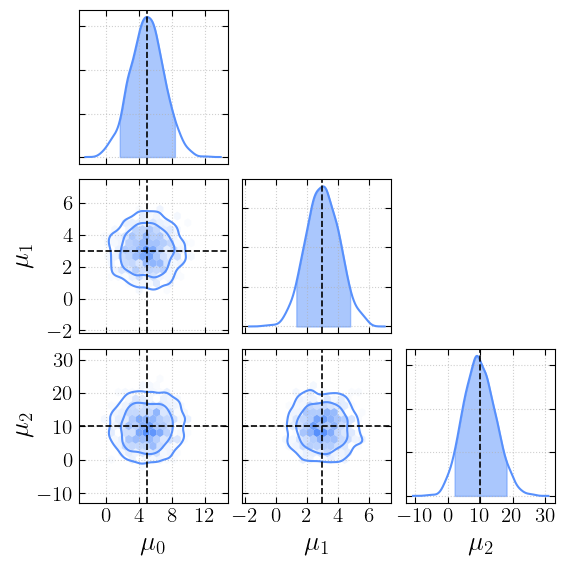

In [8]:
_ = cornerplot(samples=first_chain, truths=truths)
plt.show()

### ... plot the difference between data and injection ...

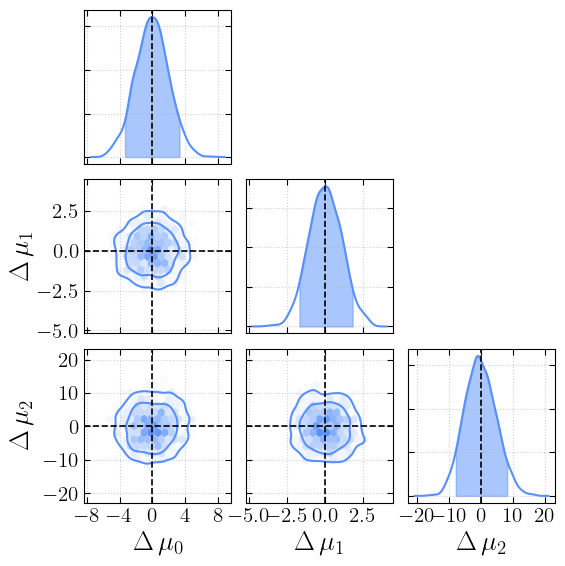

In [9]:
_ = cornerplot(samples=first_chain, truths=truths, plot_delta=True)
plt.show()

### ... add a second chain ...

In [10]:
second_chain = get_samples(mus, [1.2, 4.1, 3.7], 1000)

adding component 0
adding component 1
adding component 2


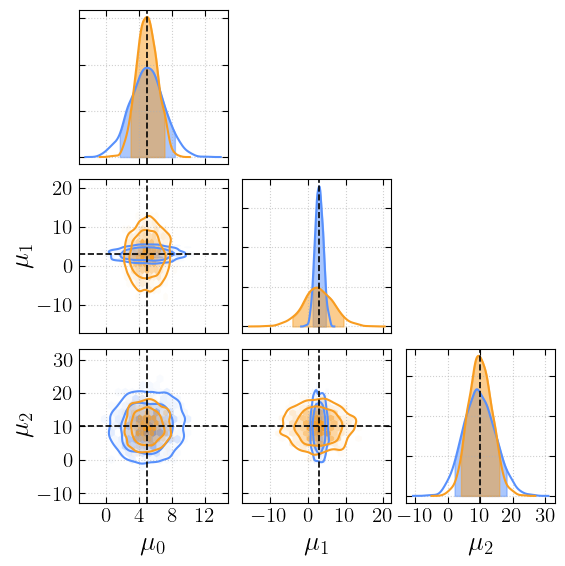

In [11]:
_ = cornerplot(samples=[first_chain, second_chain], truths=truths)
plt.show()

### ... and label them ...

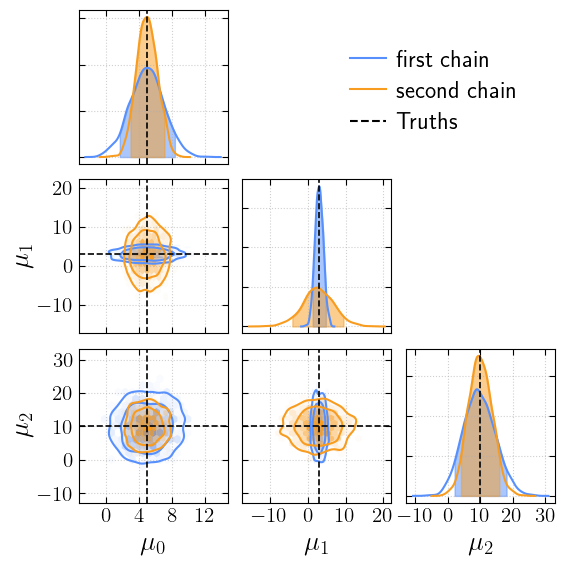

In [12]:
_ = cornerplot(samples=[first_chain, second_chain], truths=truths, chain_labels=['first chain', 'second chain'])
plt.show()

### If the ticks overlap, we can decrease their number

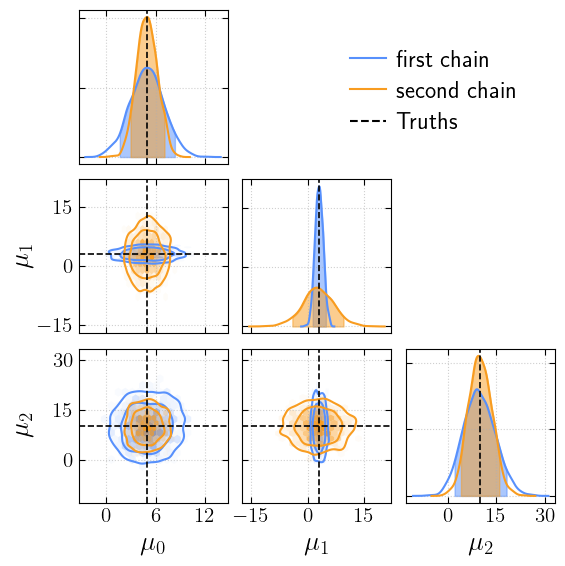

In [13]:
_ = cornerplot(samples=[first_chain, second_chain], truths=truths, chain_labels=['first chain', 'second chain'], n_ticks=3)
plt.show()